In [106]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from itertools import combinations

Load deltas in a given healpix pixel delta-healpix.fits.gz

In [107]:
deltas_path='/global/cfs/cdirs/desi/science/lya/mock_analysis/develop/ifae-ql/qq_desi_y3/v1.0.5/analysis-0/jura-124/raw_bao_unblinding/deltas_lya/Delta/'
delta_file=deltas_path+'delta-500.fits.gz' # 500 is the healpix pixel 
file = fits.open(delta_file)
num_of_skewers = len(file)-1
print(num_of_skewers)

1093


Choose redshift bin in which you want to measure the power spectrum

In [108]:
z_bin = 2.2
dz = 0.4
z_start = z_bin - dz/2
z_end = z_bin + dz/2
lam_lya = 1215.67 #Angstrom  
lamobs_start = lam_lya*(1+z_start)
lamobs_end = lam_lya*(1+z_end)
print(lamobs_start,lamobs_end)
pw_A  = 0.8
lamarray = np.arange(lamobs_start,lamobs_end,pw_A)

3647.01 4133.278


For each skewer, extract the deltas in the redshift range of measurement

In [109]:
N_FFT  = 1024
k_arr = np.fft.fftfreq(N_FFT)*2*np.pi/pw_A
lam_fft_ini = (lamobs_start+lamobs_end)/2 - pw_A*N_FFT/2
lam_fft_end = (lamobs_start+lamobs_end)/2 + pw_A*N_FFT/2
fft_array = np.linspace(lam_fft_ini,lam_fft_end,N_FFT)
extracted_deltas = []
extracted_lamobs = []
extracted_coords = []
#print(len(lamarray))
for i in range(int(num_of_skewers)):
    ihdu=i+1
    z_qso=file[ihdu].header['Z']
    lam_obs = 10.0**(file[ihdu].data['LOGLAM'])
    delta_data=file[ihdu].data['DELTA']
    
    # Also extract sightlines which partially fall in the asked redshift range 
    if np.any(lam_obs <= lamobs_start) or np.any(lam_obs >= lamobs_end):
        filtered_deltas = delta_data[(lam_obs >= lamobs_start) & (lam_obs <= lamobs_end)]
        filtered_lamobs = lam_obs[(lam_obs >= lamobs_start) & (lam_obs <= lamobs_end)]
        if len(filtered_lamobs):
            #print(filtered_lamobs.min(),filtered_lamobs.max())
            # Determine where filtered_lamobs aligns in lamarray
            start_index = np.argmin(np.abs((filtered_lamobs[0]-lamarray)))
            end_index =  np.argmin(np.abs((filtered_lamobs[-1]-lamarray)))

            # Check for length mismatch
            expected_length = end_index - start_index + 1
            if expected_length != len(filtered_deltas):
                print(f"Warning: Mismatch detected! Expected {expected_length}, got {len(filtered_deltas)}")
                # Possible fix: truncate or pad filtered_deltas
                min_length = min(expected_length, len(filtered_deltas))
                filtered_deltas = filtered_deltas[:min_length]

            #print(filtered_lamobs[0],lamarray[start_index])
            # Create a zero array of the same length as fft_array
            padded_deltas = np.zeros(N_FFT)
            #print(len(filtered_deltas),start_index-end_index)
            padded_deltas[start_index:end_index+1] = filtered_deltas  # Insert filtered deltas at the correct position

            extracted_deltas.append(padded_deltas)
            extracted_lamobs.append(filtered_lamobs)
            RA = file[ihdu].header['RA']
            DEC = file[ihdu].header['DEC']
            #print(RA,DEC)
            c = SkyCoord(ra=RA*u.rad, dec=DEC*u.rad, frame='icrs')
            extracted_coords.append(c)
            #plt.plot(fft_array,padded_deltas)
            #plt.show()
     
extracted_deltas = np.array(extracted_deltas)   
#extracted_lamobs = np.array(extracted_lamobs) 
#print(np.shape(extracted_deltas))
print('number of sightlines in the given redshift bin:',len(extracted_deltas))
N_skewers = len(extracted_deltas[:,0])

number of sightlines in the given redshift bin: 925


Fourier transform of deltas 

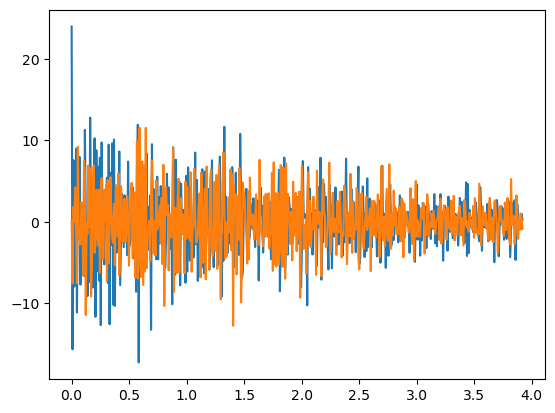

In [110]:
#delta_ft = np.zeros((len(extracted_deltas[:,0]),len(extracted_deltas[0,:])))
pad_ft  = np.zeros((len(extracted_deltas[:,0]),N_FFT),dtype=np.complex64)
#padded_deltas = np.pad(extracted_deltas, pad_width=((0, 0), (0, N_FFT - len(extracted_deltas[0,:]))), mode='constant')

for l in range(len(extracted_deltas[:,0])):
    pad_ft[l,:] = np.fft.fft(extracted_deltas[l,:])

plt.plot(k_arr[:N_FFT//2],pad_ft.real[0,:N_FFT//2])
plt.plot(k_arr[:N_FFT//2],pad_ft.imag[0,:N_FFT//2])

Angular seperation between pair of any two sightlines theta_ij

In [111]:
# Generate all unique pairs
pairs = list(combinations(range(N_skewers), 2))
#print(N_skewers)
#print(len(pairs))
# Add self-pairs
self_pairs = [(i, i) for i in range(N_skewers)]
# Combine both
all_pairs = self_pairs + pairs 
#print(all_pairs)
separations = [extracted_coords[i].separation(extracted_coords[j]).rad for i, j in all_pairs] # in radians

In [112]:
theta_ij = np.column_stack((all_pairs, separations))

In [113]:
print(theta_ij[:,2])
print(theta_ij[:,2].min(),theta_ij[:,2].max())

[0.         0.         0.         ... 0.03579985 0.01698105 0.0506611 ]
0.0 0.10525170689145989


Bin the angular separations

In [136]:
num_bins = 1000
theta_bins = np.linspace(theta_ij[:,2].min(),theta_ij[:,2].max()+0.1,num_bins)
dtheta = theta_bins[1]-theta_bins[0]
#print(dtheta,theta_bins[2]-theta_bins[1])
theta_values = theta_ij[:,2]
counts, bin_edges = np.histogram(theta_values, bins=theta_bins)

Text(0, 0.5, 'Number of Pairs')

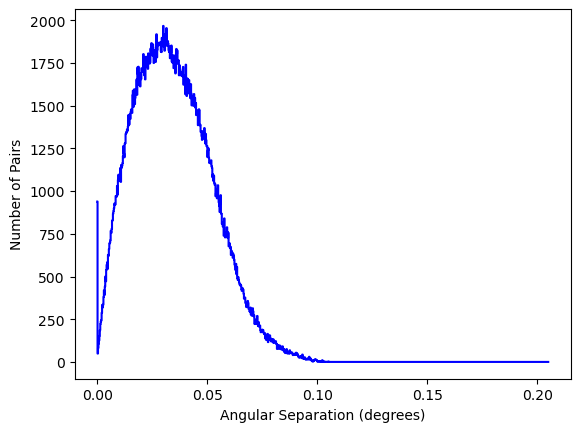

In [137]:
plt.step(bin_edges[:-1], counts, where='mid', color='b', lw=1.5)
plt.xlabel("Angular Separation (degrees)")
plt.ylabel("Number of Pairs")

Product of fourier deltas in a given angular separation bin

In [138]:
bin_indices = np.digitize(theta_values, theta_bins) - 1  # Convert to 0-based index
print(bin_indices)

[  0   0   0 ... 174  82 246]


In [139]:
print(theta_bins[bin_indices[990]], "<=", theta_values[990], "<", theta_bins[bin_indices[990]+1])

0.025682145506939428 <= 0.025858460184538256 < 0.025887602670994943


In [140]:
# Create a dictionary to store pairs for each bin
binned_pairs = {i: [] for i in range(len(theta_bins) - 1)}
print(len(theta_bins))

# Loop over bin numbers and assign the corresponding pairs
for bin_num in range(len(theta_bins) - 1):
    mask = bin_indices == bin_num  # Find all pairs that belong to this bin
    binned_pairs[bin_num] = theta_ij[mask]  
    
# Convert lists to arrays for easier indexing
for key in binned_pairs:
    binned_pairs[key] = np.array(binned_pairs[key])

# Example: Print pairs in the 10th bin
print(f"Pairs in bin 10 (θ ∈ [{theta_bins[10]:.3f}, {theta_bins[11]:.3f}]):")
print(binned_pairs[10])

1000
Pairs in bin 10 (θ ∈ [0.002, 0.002]):
[[0.00000000e+00 9.09000000e+02 2.11048705e-03]
 [2.00000000e+00 5.59000000e+02 2.14277016e-03]
 [4.00000000e+00 5.30000000e+01 2.20247680e-03]
 [7.00000000e+00 1.80000000e+02 2.16449400e-03]
 [7.00000000e+00 7.73000000e+02 2.06185020e-03]
 [8.00000000e+00 4.00000000e+02 2.08965052e-03]
 [9.00000000e+00 9.22000000e+02 2.10089295e-03]
 [1.30000000e+01 6.88000000e+02 2.13489364e-03]
 [1.50000000e+01 4.62000000e+02 2.20847964e-03]
 [1.50000000e+01 5.70000000e+02 2.09959544e-03]
 [1.60000000e+01 2.85000000e+02 2.25626688e-03]
 [1.60000000e+01 8.32000000e+02 2.07668290e-03]
 [1.70000000e+01 5.41000000e+02 2.12819373e-03]
 [1.80000000e+01 1.81000000e+02 2.08444368e-03]
 [1.80000000e+01 9.17000000e+02 2.18345975e-03]
 [1.90000000e+01 2.21000000e+02 2.19116854e-03]
 [3.40000000e+01 2.93000000e+02 2.22509495e-03]
 [3.40000000e+01 5.73000000e+02 2.05650297e-03]
 [3.60000000e+01 8.45000000e+02 2.08663098e-03]
 [3.70000000e+01 6.80000000e+01 2.18940521e-0

In [141]:
binned_products = {}

for bin_num, pairs in binned_pairs.items():
    i_indices = pairs[:, 0].astype(int)
    j_indices = pairs[:, 1].astype(int)

    # Compute pairwise products of pad_fts
    products = pad_ft[i_indices] * np.conj(pad_ft[j_indices])  # Cross power spectrum
    
    binned_products[bin_num] = products  

# Convert lists to arrays
for key in binned_products:
    #if binned_products[key]:  # Avoid empty bins
    binned_products[key] = np.array(binned_products[key])
    #else:
    #    binned_products[key] = np.zeros((0, pad_ft.shape[1]))  # Empty bin placeholder

print(np.shape(binned_products[50]))

# Example: Print the product for bin 10
print(f"Product of pad_ft for pairs in bin 10 (θ ∈ [{theta_bins[10]:.3f}, {theta_bins[11]:.3f}]):")
print(len(binned_products))

print(binned_products[0])
print(np.sum(binned_products[0],axis=0))

(1061, 1024)
Product of pad_ft for pairs in bin 10 (θ ∈ [0.002, 0.002]):
999
[[577.25806  +0.0000000e+00j 304.56522  -2.0190587e-06j
   60.779705 -3.8865630e-07j ...  63.844498 +7.8639957e-09j
   60.779705 +3.8865630e-07j 304.56522  +2.0190587e-06j]
 [  9.031886 +0.0000000e+00j   2.1274261-7.5572686e-09j
   17.369967 +2.3743723e-07j ... 106.55913  -5.1774441e-07j
   17.369967 -2.3743723e-07j   2.1274261+7.5572686e-09j]
 [211.42896  +0.0000000e+00j 143.60226  +4.7630203e-07j
   61.094692 +1.7485485e-07j ...  56.950016 -1.4949001e-07j
   61.094692 -1.7485485e-07j 143.60226  -4.7630203e-07j]
 ...
 [ -1.9400908-0.0000000e+00j   9.173104 -1.2475305e+00j
   -3.613524 -1.2675217e+01j ...  -7.1247907-6.4995773e-02j
   -3.613524 +1.2675217e+01j   9.173104 +1.2475305e+00j]
 [ -7.3601875-0.0000000e+00j  -4.0248218+4.2464848e+01j
    7.507695 +8.7743973e+01j ...  27.181816 -1.2399315e+02j
    7.507695 -8.7743973e+01j  -4.0248218-4.2464848e+01j]
 [-71.8188   -0.0000000e+00j -26.42982  +6.5301888e+0

In [142]:
Pcross = np.zeros((num_bins,N_FFT))
#print(binned_products[0][1,])
for ind in range(num_bins-1):
    Pcross[ind][:] = np.sum(binned_products[ind],axis=0).real

Text(0, 0.5, 'P($k$) [A]')

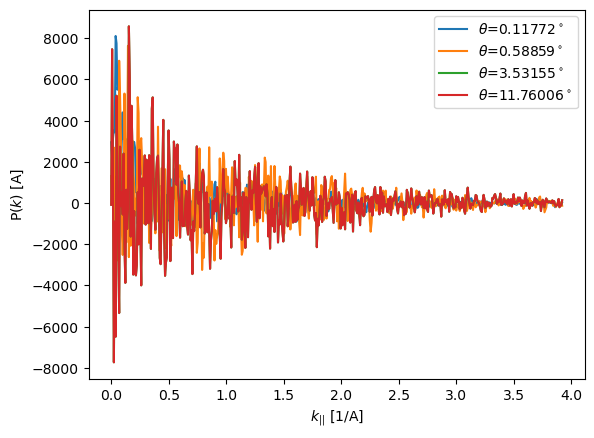

In [143]:
#plt.plot(k_arr[:N_FFT//2],k_arr[:N_FFT//2]*pw_A/N_FFT*1/N_skewers*Pcross[0][:N_FFT//2]/np.pi,label=r'$\theta$=%0.5f$^\circ$'%(180*theta_bins[0]/np.pi))
plt.plot(k_arr[:N_FFT//2],Pcross[10][:N_FFT//2],label=r'$\theta$=%0.5f$^\circ$'%(180*theta_bins[10]/np.pi))
plt.plot(k_arr[:N_FFT//2],Pcross[70][:N_FFT//2],label=r'$\theta$=%0.5f$^\circ$'%(180*theta_bins[50]/np.pi))
plt.plot(k_arr[:N_FFT//2],Pcross[190][:N_FFT//2],label=r'$\theta$=%0.5f$^\circ$'%(180*theta_bins[300]/np.pi))
plt.plot(k_arr[:N_FFT//2],Pcross[190][:N_FFT//2],label=r'$\theta$=%0.5f$^\circ$'%(180*theta_bins[-1]/np.pi))
data = np.loadtxt('/global/cfs/cdirs/desi/users/sindhu_s/fourier_playground/fft_px/p1d_foresflow_z3.csv',delimiter=',')
#plt.plot(data[:,0],data[:,1],label='Forestflow')# kp in Mpc^-1 and Pk dimensionless
plt.legend()
plt.xlabel('$k_{||}$ [1/A]')
plt.ylabel('P($k$) [A]')
#plt.savefig('px_IFAE_z3p0_theta_evolution.png',dpi=400,bbox_inches='tight')
#plt.savefig('px_IFAE_z3p0_forestflow_compare.png',dpi=400,bbox_inches='tight')

In [144]:
p1d_km = pw_A/N_FFT*1/N_skewers*np.sum(np.abs(pad_ft)**2,axis=0) # Ignored the resolution function R_a(x)

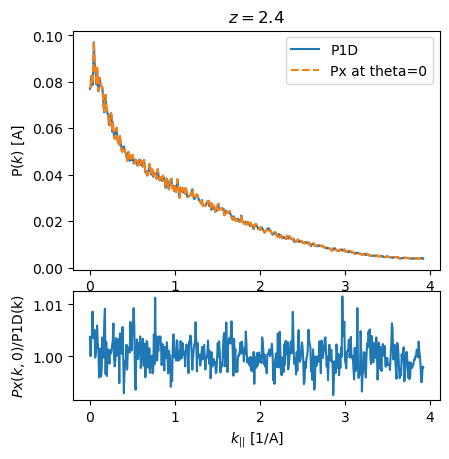

In [145]:
ax1 = plt.subplot2grid((3, 4), (0, 0), colspan=3, rowspan=2) 
ax2 = plt.subplot2grid((3, 4), (2, 0), colspan=3,rowspan=2)

ax1.plot(k_arr[:N_FFT//2],p1d_km[:N_FFT//2],label='P1D')
ax1.plot(k_arr[:N_FFT//2],pw_A/N_FFT*1/N_skewers*Pcross[0][:N_FFT//2],label='Px at theta=0',linestyle='--')

#ax1.plot(k_arr[:N_FFT//2],np.sum(np.abs(pad_ft)**2,axis=0)[:N_FFT//2]) # un normalised

karr = np.load('p1d_ml24_z2p2.npz')['x']
p1d = np.load('p1d_ml24_z2p2.npz')['z']

#ax1.plot(karr,p1d,linestyle='dotted')

ax2.plot(k_arr[:N_FFT//2],pw_A/N_FFT*1/N_skewers*Pcross[0][:N_FFT//2]/p1d_km[:N_FFT//2])
#print(pw_A/N_FFT*1/N_skewers*Pcross[0][:N_FFT//2]/p1d_km[:N_FFT//2])
#plt.plot(k_arr[:N_FFT//2],Pcross[0][:N_FFT//2]/p1d_km[:N_FFT//2])
#print(Pcross[0][:N_FFT//2]/p1d_km[:N_FFT//2])
ax1.set_title('$z=2.4$')
ax2.set_xlabel('$k_{||}$ [1/A]')
ax1.set_ylabel('P($k$) [A]')
ax2.set_ylabel('$Px(k,0)$/P1D(k)')
#ax1.set_xlim(-0.1,1)
#ax2.set_xlim(-0.1,1)
ax1.legend()
data = np.loadtxt('/global/cfs/cdirs/desi/users/sindhu_s/fourier_playground/fft_px/p1d_foresflow_z3.csv',delimiter=',')
#ax1.plot(data[:,0],data[:,1])
plt.savefig('px_ifae_vs_p1d_z2.4_ratio_1kthetabins.png',dpi=400,bbox_inches='tight')